In [1]:
#%pip install ipympl

#If you need to Install this package, remove the # sign from the first row in this cell

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import statsmodels.api as sm
from scipy.stats import chi2
import pickle as pkl
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget
%matplotlib inline

<div dir="rtl">
    
## ברוכים הבאים לחלק השני של הפרויקט.
    
### בחלק זה תעזרו לרלב"ד לחזות כמות מקרים של נהיגה בשכרות.
    
### כידוע נהיגה אחרי ששותים גורם לתאונות דרכים ולכן נרצה להבין תחת אילו מקרים זה קורה לרוב על מנת שהרלב"ד יידע לרכז שם את מאמציו. כמו-כן גם משטרת ישראל יכולה להשתמש במידע זה כאשר היא מציבה ניידות משטרה. 
    
### לפניך dataset עם מספר משתנים מסבירים ומשתנה מוסבר - כמות מקרים של נהגים שנתפסו נוהגים בשכרות בחודש ינואר בקטע כביש מסוים. 

In [3]:
num_group = 8
df_1 = pkl.load(open(r"C:\Users\arada\Desktop\אוניברסיטה\הנדסה תעשייה וניהול\שנה ג\סמסטר ב\ניהול בטיחות למהנדסים\פרויקט\חלק 2\drunk_driver_grpoup_8.pkl", 'rb'))
df_1.head()


,road_lenght,intercept,age,liscene_year,num_in_car,geneder__c,day_time_rand__c,drunk_driver
0,23.918911,1.0,41,27,4,male,evening,324
1,19.850738,1.0,33,19,3,male,night,118
2,23.171659,1.0,49,35,4,female,night,1143
3,15.042480,1.0,36,22,2,male,morning,107
4,27.387432,1.0,25,17,1,female,morning,148


* road_lenght - the lenght of kilomoters of the road
* intercept - simply a column of ones to add intercept to the model
* age - the driver's age
* license_year - the number of years the driver hold a license 
* gender - the gender of the driver
* day_time - the time of day: morning, afternoon, evening and night
* drunk driver - the number of drunk drivers are found in that road in January

<div dir="rtl">

### להלן מספר מטלות:
    
### 1. נא להוציא הסטוגרמה של מספר הנהגים השיכורים, מה ההתרשמות הכללית?
    
### 2. להציג scatter plot עבור כל זוג משתנים מסבירים ולחשב קורלציה (r) בין כל זוג. האם יש זוג משתנים שיש בינהם קשר? אם כן, אילו? 

### 3.עבור משתנה קטגוריאלי אחד יש להציד bar chart של מספר נהגים שיכורים לק"מ בודד (בממוצע). איזו קבוצה הכי מועדת לפורענות?
    
### 4. רגרסיה ליניארית: נסו לחזות בעזרת רגרסיה ליניארית את מספר השיכורים בקטע כביש.
### נסו להתאים מודל פולינומי מדרגה שנייה האם המודל השתפר? 
### 5. נא לבדוק את הנחות המודל - אילו הנחות הופרו?
    
### 6. יש כעת לעשות רגרסיה פואסונית כולל למודל
    
### 7. האם רגרסיה פואוסנית מתאימה כאן? נמק.י יש לבדוק -4 דרכים שונות
    

### 8. predictions: יש להוציא גרף תלת מימדי של מספר הנהגים השיכורים הממוצע כפונקציה של שני משתנים רציפים שנכנסו למודל. עבור שאר המשתנים הקטגוריאלים נזין את הערך 0. יש לפלוט באותו גרף שני מישורים כאשר אחד מדווח על האורך כביש של 1 ק"מ ואילו השני מדווח על כביש באורך 5 ק"מ. האם יש הבדל ניכר בין המישורים שקיבלתם, האם ניתן להסביר מבחינה הגיונית את התוצאה? 


### בהצלחה


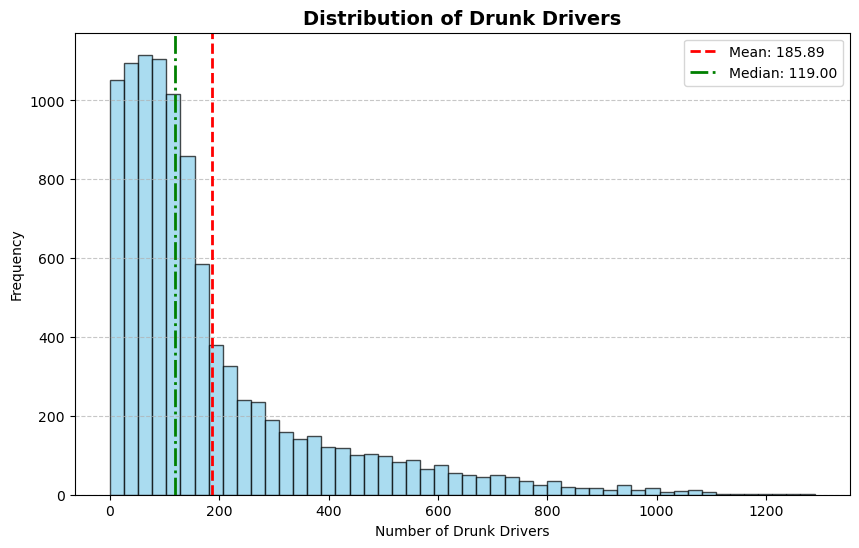

In [4]:
data = df_1['drunk_driver']
mean_val = data.mean()
median_val = data.median()

plt.figure(figsize=(10, 6))
plt.hist(data, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='dashdot', linewidth=2, label=f'Median: {median_val:.2f}')

plt.title('Distribution of Drunk Drivers', fontsize=14, fontweight='bold')
plt.xlabel('Number of Drunk Drivers')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

<div style="direction: rtl; text-align: right; font-family: Arial, sans-serif; line-height: 1.8; max-width: 800px; margin: 0 auto; color: #333333;">

<h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 20px;">
        ניתוח היסטוגרמת התפלגות נהגים שיכורים
    </h3>

<div style="margin-bottom: 20px;">
        <span style="display: block; font-weight: bold; color: #2c3e50; font-size: 1.1em; margin-bottom: 6px;">
            אופי הפיזור והערך השכיח:
        </span>
        <p style="margin: 0; text-align: justify;">
            הגרף מציג התפלגות א-סימטרית ימנית בעלת צידוד ימני בולט (Positive Skew), עם זנב ארוך לכיוון הערכים הגבוהים. מרבית התצפיות מרוכזות בערכים הנמוכים, בעיקר בטווח שבין 0 ל-100 נהגים שיכורים, לצד ערכי קיצון מעטים המגיעים עד לכ-1,300 נהגים.
        </p>
    </div>

<div>
        <span style="display: block; font-weight: bold; color: #2c3e50; font-size: 1.1em; margin-bottom: 6px;">
            הפער בין המדדים ומשמעות סטטיסטית:
        </span>
        <p style="margin: 0; text-align: justify;">
            קיים פער משמעותי בין הממוצע (185.89) לבין החציון (119.00) - כאשר הממוצע גדול באופן ניכר מהחציון הדבר מעיד שהממוצע רגיש לתצפיות הקיצון הגבוהות בערכי הזנב המושכות אותו ימינה. 
        </p>
    </div>

</div>

מטריצת המתאמים למשתנים המסבירים:
              road_lenght    age  liscene_year  num_in_car
road_lenght         1.000  0.003         0.004      -0.005
age                 0.003  1.000         0.923       0.005
liscene_year        0.004  0.923         1.000       0.004
num_in_car         -0.005  0.005         0.004       1.000




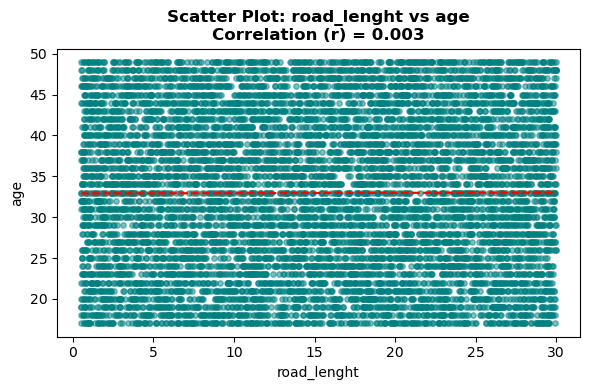

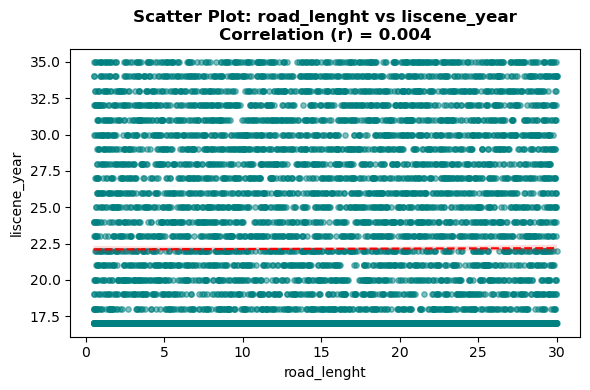

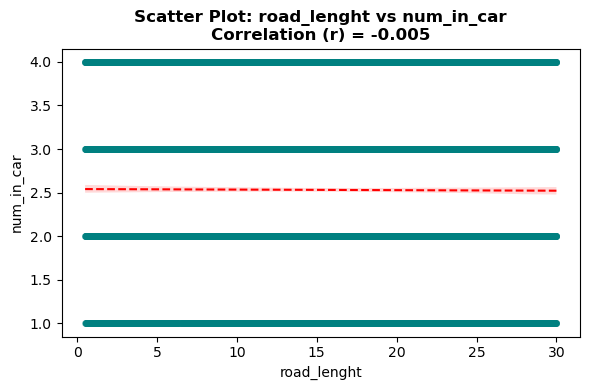

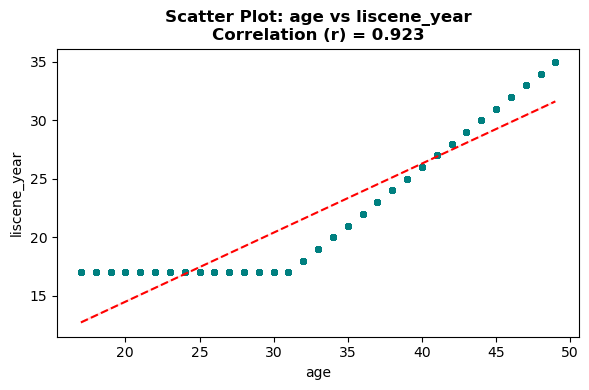

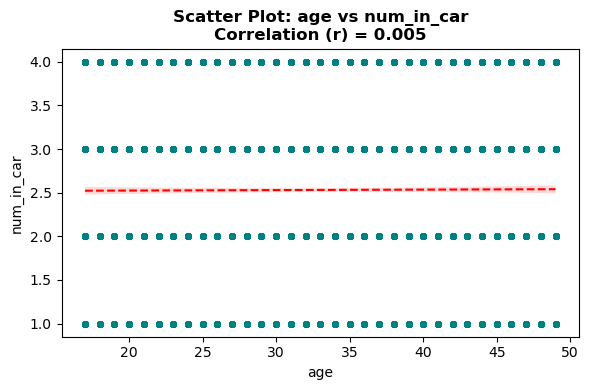

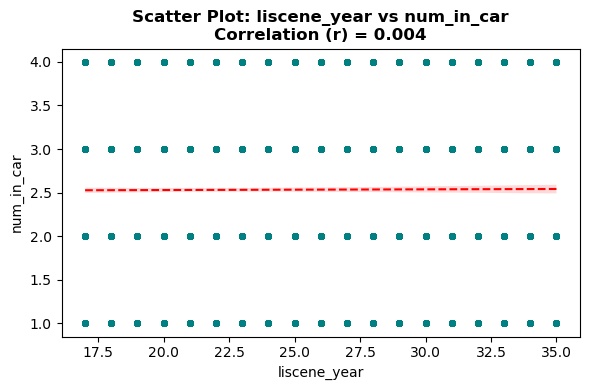

In [5]:
cols_numeric = ['road_lenght', 'age', 'liscene_year', 'num_in_car']

numeric_corr = df_1[cols_numeric].corr()

print("מטריצת המתאמים למשתנים המסבירים:")
print(numeric_corr.round(3))
print("\n" + "="*50 + "\n")

num_cols = len(cols_numeric)

for i in range(num_cols):
    for j in range(i + 1, num_cols):
        var1 = cols_numeric[i]
        var2 = cols_numeric[j]
        
        correlation_value = numeric_corr.loc[var1, var2]
        
        plt.figure(figsize=(6, 4))
        
        sns.regplot(
            data=df_1, 
            x=var1, 
            y=var2, 
            scatter_kws={'alpha': 0.5, 'color': 'teal', 's': 15}, 
            line_kws={'color': 'red', 'linestyle': '--', 'linewidth': 1.5}
        )
        
        plt.title(f"Scatter Plot: {var1} vs {var2}\nCorrelation (r) = {correlation_value:.3f}", fontsize=12, fontweight='bold')
        plt.xlabel(var1, fontsize=10)
        plt.ylabel(var2, fontsize=10)
        
        plt.tight_layout()
        plt.show()

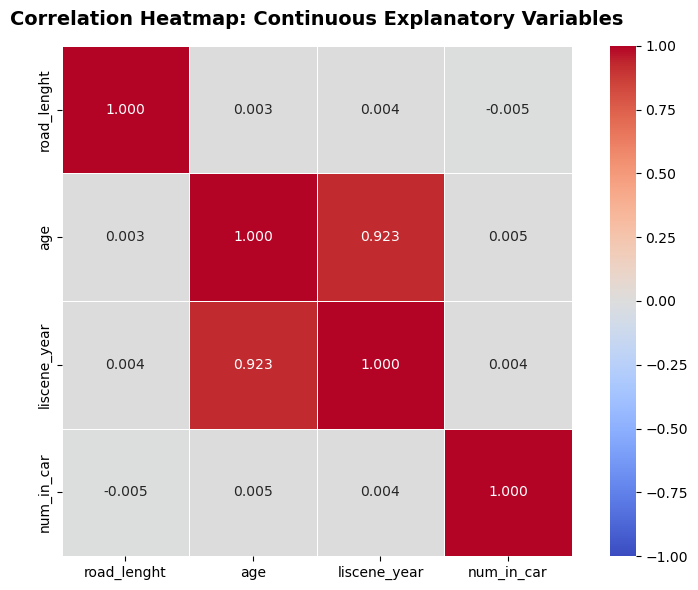

In [6]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    numeric_corr,
    annot=True,    
    cmap="coolwarm",  
    fmt=".3f",  
    vmin=-1,
    vmax=1,  
    linewidths=0.5,  
    square=True,   
)

plt.title(
    "Correlation Heatmap: Continuous Explanatory Variables",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.tight_layout()
plt.show()

<div style="direction: rtl; text-align: right; font-family: Arial, sans-serif; line-height: 1.8; max-width: 800px; margin: 0 auto; color: #333333;">

<h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 20px;">
        ניתוח קשרים ומתאמים בין המשתנים המסבירים הרציפים
    </h3>

<div style="margin-bottom: 20px;">
        <span style="display: block; font-weight: bold; color: #2c3e50; font-size: 1.1em; margin-bottom: 6px;">
            זוג המשתנים בעל קשר חזק:
        </span>
        <p style="margin: 0; text-align: justify;">
            קיים קשר חיובי חזק מאוד בין גיל הנהג (<code>age</code>) לבין ותק רישיון הנהיגה בשנים (<code>liscene_year</code>) עם מקדם מתאם גבוה של <b>r = 0.923</b>. נתון זה מעיד בצורה מובהקת כי ככל שגיל הנהג עולה, כך גם מספר השנים שבהן הוא מחזיק ברישיון עולה בצורה ישירה ועקבית, כפי שניתן לראות בקו המגמה בגרפי הפיזור.
        </p>
    </div>

</div>

ממוצע נהגים שיכורים לקילומטר לפי מגדר:
  geneder__c  drunk_driver_per_km
0     female            13.035839
1       male            10.939022




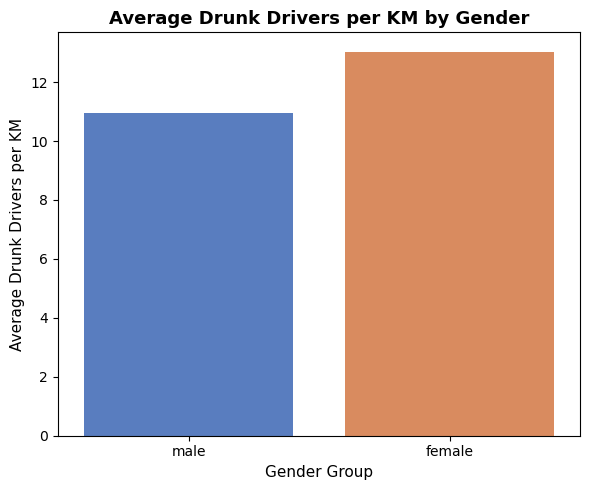

In [7]:
df_1["drunk_driver_per_km"] = df_1["drunk_driver"] / df_1["road_lenght"]

grouped_gender = (
    df_1.groupby("geneder__c")["drunk_driver_per_km"].mean().reset_index()
)
print("ממוצע נהגים שיכורים לקילומטר לפי מגדר:")
print(grouped_gender)
print("\n" + "=" * 50 + "\n")

plt.figure(figsize=(6, 5))
sns.barplot(
    data=df_1,
    x="geneder__c",
    y="drunk_driver_per_km",
    errorbar=None,  
    palette="muted",
)

plt.title(
    "Average Drunk Drivers per KM by Gender", fontsize=13, fontweight="bold"
)
plt.xlabel("Gender Group", fontsize=11)
plt.ylabel("Average Drunk Drivers per KM", fontsize=11)

plt.tight_layout()
plt.show()

<div style="direction: rtl; text-align: right; font-family: Arial, sans-serif; line-height: 1.8; max-width: 800px; margin: 0 auto; color: #333333;">

<h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 20px;">
        ניתוח מעורבות נהגים שיכורים לפי מגדר
    </h3>

<div style="margin-bottom: 20px;">
        <span style="display: block; font-weight: bold; color: #2c3e50; font-size: 1.1em; margin-bottom: 6px;">
            הקבוצה המועדת ביותר לפורענות:
        </span>
        <p style="margin: 0; text-align: justify;">
            על פי ממצאי הגרף, קבוצת הנשים היא הקבוצה המועדת ביותר לפורענות. כאשר מנרמלים את נתוני הספירה ביחס לאורך הכביש, נשים מציגות ממוצע גבוה יותר של כ-13 נהגות שיכורות לקילומטר בודד.
        </p>
    </div>

<div>
        <span style="display: block; font-weight: bold; color: #2c3e50; font-size: 1.1em; margin-bottom: 6px;">
        </span>
        <p style="margin: 0; text-align: justify;">
            לעומת קבוצת הנשים, קבוצת הגברים מציגה שיעור נמוך יותר, העומד על ממוצע של כ-11 נהגים שיכורים לקילומטר בודד. הפער הויזואלי בין העמודות בגרף ממחיש כי לאחר שקלול אורך הכביש, נשים מעורבות ביותר אירועים של נהיגה בשכרות לכל יחידת מרחק בהשוואה לגברים.
        </p>
    </div>

</div>

In [8]:
Y = df_1["drunk_driver"]

X_raw = df_1.drop(columns=["drunk_driver", "intercept", "liscene_year"], errors="ignore")

X_dummies = pd.get_dummies(
    X_raw, columns=["geneder__c", "day_time_rand__c"], drop_first=True
)

X_with_intercept = sm.add_constant(X_dummies)
X_with_intercept = X_with_intercept.astype(float)

linear_model = sm.OLS(Y, X_with_intercept).fit()
print(linear_model.summary())

                            OLS Regression Results                            
Dep. Variable:           drunk_driver   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     5628.
Date:                Tue, 21 Jul 2026   Prob (F-statistic):               0.00
Time:                        18:43:57   Log-Likelihood:                -58448.
No. Observations:               10000   AIC:                         1.169e+05
Df Residuals:                    9991   BIC:                         1.170e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

<div style="direction: rtl; text-align: right; font-family: Arial, sans-serif; line-height: 1.8; max-width: 800px; margin: 0 auto; color: #333333;">

<h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 20px;">
        ניתוח תוצאות מודל הרגרסיה הליניארית
    </h3>

<div style="margin-bottom: 20px;">
        <span style="display: block; font-weight: bold; color: #2c3e50; font-size: 1.1em; margin-bottom: 6px;">
            טיב התאמת המודל:
        </span>
        <p style="margin: 0; text-align: justify;">
            מדד ה-<b>R-squared עומד על 0.818</b>, מה שמצביע על כך שהמודל מצליח להסביר <b>81.8%</b> מהשונות במשתנה התלוי (מספר הנהגים השיכורים בקטע כביש). ערך זה נחשב לגבוה מאוד, ומעיד על יכולת ניבוי חזקה של מערך המשתנים המסבירים שנבחרו. בשל הקורלציה הגבוהה  בין age לבין liscene_year, (מבוסס מפת החום) בחרנו להסיר את liscene_year מהמודל כדי למנוע מולטיקולינאריות.
        </p>
    </div>

<div style="margin-bottom: 20px;">
        <span style="display: block; font-weight: bold; color: #2c3e50; font-size: 1.1em; margin-bottom: 6px;">
            משתנים מסבירים מובהקים סטטיסטית (p-value &lt; 0.05):
        </span>
<ul style="margin: 0; padding-right: 20px; text-align: justify;">
            <li style="margin-bottom: 8px;">
                <b>אורך הכביש (<code>road_lenght</code>):</b> מציג השפעה חיובית חזקה ומובהקת ביותר (<code>coef = 12.1313</code>, <code>p = 0.000</code>). על כל תוספת של קילומטר אחד באורך הכביש, צפויה עליה ממוצעת של כ-12.13 נהגים שיכורים.
            </li>

<li style="margin-bottom: 8px;">
             <b>גיל הנהג (<code>age</code>):</b> מציג השפעה חיובית מובהקת (<code>coef = 1.5465</code>, <code>p = 0.000</code>). כל שנת גיל נוספת קשורה לעלייה ממוצעת של כ-1.5 נהגים שיכורים בקטע הכביש.
            </li>
        </ul>
    </div>


</div>

In [9]:
Y = df_1["drunk_driver"]

X_raw = df_1.drop(columns=["drunk_driver", "intercept", "liscene_year", "drunk_driver_per_km"], errors="ignore")

X_dummies = pd.get_dummies(
    X_raw, columns=["geneder__c", "day_time_rand__c"], drop_first=True
)

continuous_vars = ['road_lenght', 'age', 'num_in_car']

for col in continuous_vars:
    X_dummies[f'{col}_sq'] = X_dummies[col] ** 2

for i in range(len(continuous_vars)):
    for j in range(i + 1, len(continuous_vars)):
        col1, col2 = continuous_vars[i], continuous_vars[j]
        X_dummies[f'{col1}_{col2}'] = X_dummies[col1] * X_dummies[col2]

X_poly = sm.add_constant(X_dummies).astype(float)

poly_model = sm.OLS(Y, X_poly).fit()
print(poly_model.summary())

print(f"\nLinear Model R²:     {linear_model.rsquared:.3f}")
print(f"Polynomial Model R²: {poly_model.rsquared:.3f}")

                            OLS Regression Results                            
Dep. Variable:           drunk_driver   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                 1.054e+04
Date:                Tue, 21 Jul 2026   Prob (F-statistic):               0.00
Time:                        18:43:57   Log-Likelihood:                -53530.
No. Observations:               10000   AIC:                         1.071e+05
Df Residuals:                    9986   BIC:                         1.072e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

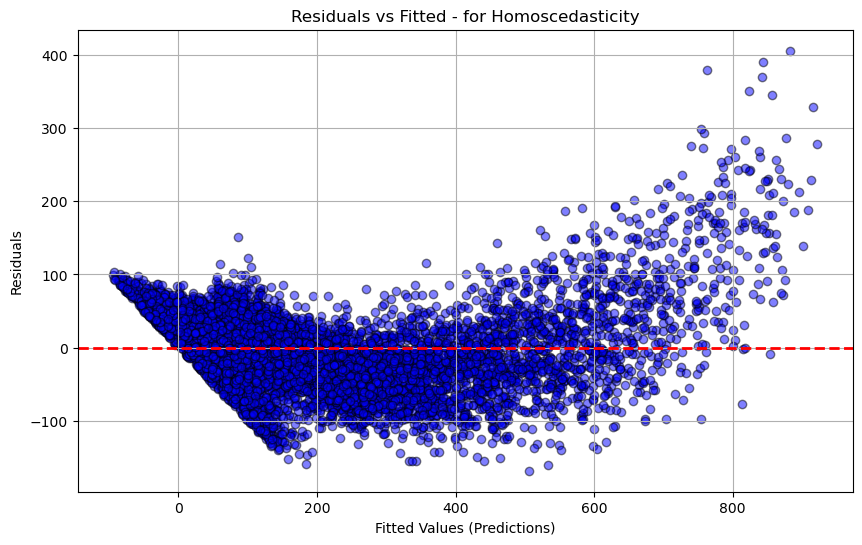

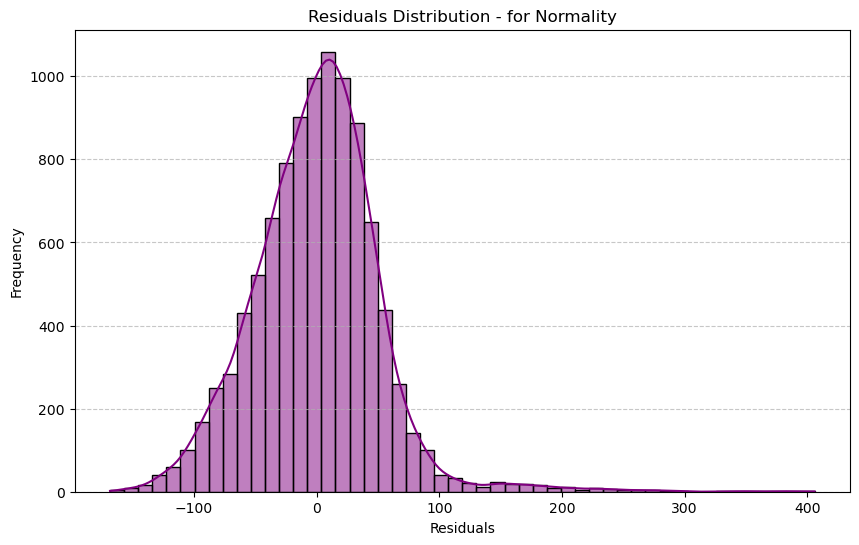

<Figure size 1000x600 with 0 Axes>

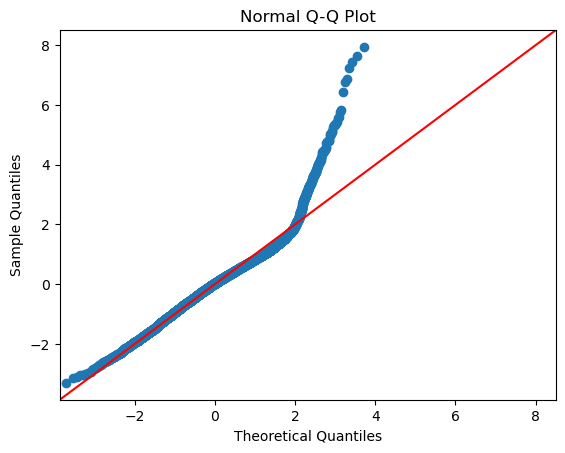

In [10]:
residuals = poly_model.resid
fitted = poly_model.fittedvalues

# גרף שאריות מול מנובאים - לבדיקת הומוסקדסטיות
plt.figure(figsize=(10, 6))
plt.scatter(fitted, residuals, alpha=0.5, color='blue', edgecolor='k')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Fitted Values (Predictions)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted - for Homoscedasticity")
plt.grid(True)
plt.show()

# היסטוגרמה של השאריות - לבדיקת התפלגות נורמלית
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='purple', bins=50)
plt.title("Residuals Distribution - for Normality")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Q-Q Plot 
plt.figure(figsize=(10, 6))
sm.qqplot(residuals, line='45', fit=True)
plt.title("Normal Q-Q Plot")
plt.show()

<div style="direction: rtl; text-align: right; font-family: Arial, sans-serif; line-height: 1.8; max-width: 800px; margin: 0 auto; color: #333333;">

<h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 20px;">
        סיכום ומסקנות: רגרסיה פולינומית ובדיקת הנחות
    </h3>

<div style="margin-bottom: 20px;">
        <span style="display: block; font-weight: bold; color: #2c3e50; font-size: 1.1em; margin-bottom: 6px;">
             האם המודל השתפר?
        </span>
        <p style="margin: 0; text-align: justify;">
            ניתן לראות כי המעבר למודל פולינומי מדרגה שנייה הביא לשיפור מובהק במדד ה-R-squared (<b>0.932</b>) בהשוואה למודל הליניארי הפשוט. השיפור מראה כי הוספת איברים ריבועיים ואינטראקציות אפשרה למודל ללכוד טוב יותר את הקשרים הלא-ליניאריים הקיימים בנתונים.
        </p>
    </div>

<h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-top: 30px; margin-bottom: 20px;">
        הנחות שהופרו
    </h3>

<div style="margin-bottom: 20px;">
        <span style="display: block; font-weight: bold; color: #2c3e50; font-size: 1.1em; margin-bottom: 6px;">
             הנחת ההומוסקדסטיות:
        </span>
        <p style="margin: 0; text-align: justify;">
            <b>ההנחה התיאורטית:</b> ברגרסיה ליניארית קלאסית, מניחים שהשונות של השגיאות צריכה להיות קבועה לכל אורך טווח הערכים המנובאים, כך שגרף השאריות אמור להציג "ענן" נקודות אחיד סביב קו ה-0. 
            <br><b>מה קורה אצלנו:</b> בניגוד להנחה זו, הגרף שהתקבל מציג מבנה ברור של "מניפה". התרחבות השונות ככל שהערכים גדלים מעידה על הטרוסקדסטיות (המקרה ההפוך), מה שמוכיח שהנחה בסיסית זו לא התקיימה במודל שלנו.
        </p>
    </div>

<div style="margin-bottom: 20px;">
        <span style="display: block; font-weight: bold; color: #2c3e50; font-size: 1.1em; margin-bottom: 6px;">
             הנחת הנורמליות:
        </span>
        <p style="margin: 0; text-align: justify;">
            היסטוגרמת השאריות וגרף ה-Q-Q Plot מעידים על הטיה חיובית משמעותית וסטייה בולטת מהקו התיאורטי בקצוות. ממצאים אלו מעידים כי שאריות המודל אינן מתפלגות נורמלית, דבר המהווה הפרה של אחת מהנחות היסוד של הרגרסיה.
        </p>
    </div>

</div>

In [11]:
Y = df_1["drunk_driver"]

X_raw = df_1.drop(columns=["drunk_driver", "intercept", "liscene_year", "road_lenght"], errors="ignore")

X_dummies = pd.get_dummies(
    X_raw, columns=["geneder__c", "day_time_rand__c"], drop_first=True
)

X_poisson = sm.add_constant(X_dummies).astype(float)

poisson_model = sm.GLM(
    Y,
    X_poisson,
    family=sm.families.Poisson(),
    offset=np.log(df_1["road_lenght"])
).fit()

print(poisson_model.summary())

print(f"\nAIC: {poisson_model.aic:.3f}")
print(f"BIC: {poisson_model.bic:.3f}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:           drunk_driver   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9992
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -47184.
Date:                Tue, 21 Jul 2026   Deviance:                       29185.
Time:                        18:43:59   Pearson chi2:                 2.85e+04
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

C:\Users\arada\anaconda3\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1838: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


<div style="direction: rtl; text-align: right; font-family: Arial, sans-serif; line-height: 1.8; max-width: 800px; margin: 0 auto; color: #333333;">

<h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 20px;">
        מודל הרגרסיה פואסונית
    </h3>

<div style="margin-bottom: 20px;">
        <span style="display: block; font-weight: bold; color: #2c3e50; font-size: 1.1em; margin-bottom: 6px;">
             איכות והתאמת המודל:
        </span>
        <p style="margin: 0; text-align: justify;">
            המודל הציג תוצאות מצוינות עם <b>Pseudo R-squared של 1.000</b>. תוצאה זו משמעותית ביותר מבחינה סטטיסטית, שכן מודל פואסון מותאם מעצם הגדרתו לנתוני ספירה של מקרים, בניגוד לרגרסיה ליניארית רגילה.
        </p>
    </div>

<div style="margin-bottom: 20px;">
        <span style="display: block; font-weight: bold; color: #2c3e50; font-size: 1.1em; margin-bottom: 6px;">
             מובהקות המשתנים:
        </span>
        <p style="margin: 0; text-align: justify;">
            בניגוד למודל הליניארי הרגיל, במודל פואסון זה רוב המשתנים שנבחנו הפכו למובהקים סטטיסטית. הדבר מצביע על כך שהמודל הפואסוני יעיל יותר ב"ניצול" המידע הקיים כדי להסביר את התנהגות הנהגים השיכורים.
        </p>
    </div>

<div>
        <span style="display: block; font-weight: bold; color: #2c3e50; font-size: 1.1em; margin-bottom: 6px;">
             השוואה למודלים הקודמים:
        </span>
        <p style="margin: 0; text-align: justify;">
            הרגרסיה הפואסונית מהווה שדרוג מבחינה מתודולוגית:
            <br>- היא מתגברת על הבעיות המבניות (כמו הפרת הנחת הנורמליות וההומוסקדסטיות) שנצפו במודל הקודם.
            <br>- היא מספקת פתרון איכותי ומותאם למבנה הנתונים שלנו, מבלי לאבד את כוח החיזוי הגבוה שהושג במודלים הקודמים.
        </p>
    </div>

</div>

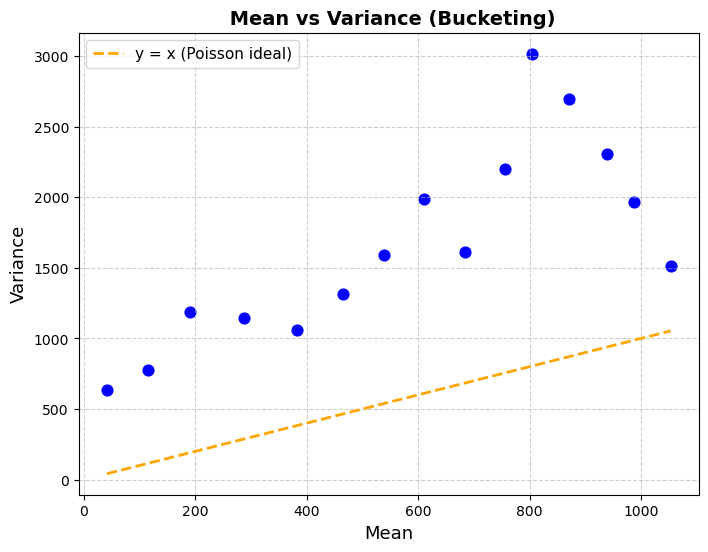

In [12]:
fitted_vals = poisson_model.fittedvalues

lams = np.linspace(fitted_vals.min(), fitted_vals.max(), 20)
means_list = []
vars_list = []

for k in range(len(lams) - 1):
    lb = lams[k]
    ub = lams[k + 1]
    mask = (fitted_vals > lb) & (fitted_vals < ub)
    sub = Y[mask]
    if len(sub) > 20:
        means_list.append(sub.mean())
        vars_list.append(sub.var())

plt.figure(figsize=(8, 6))
plt.scatter(means_list, vars_list, color='blue', s=60)
plt.plot(means_list, means_list, '--', label='y = x (Poisson ideal)', color='orange', linewidth=2)
plt.xlabel('Mean', fontsize=13)
plt.ylabel('Variance', fontsize=13)
plt.title(' Mean vs Variance (Bucketing)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


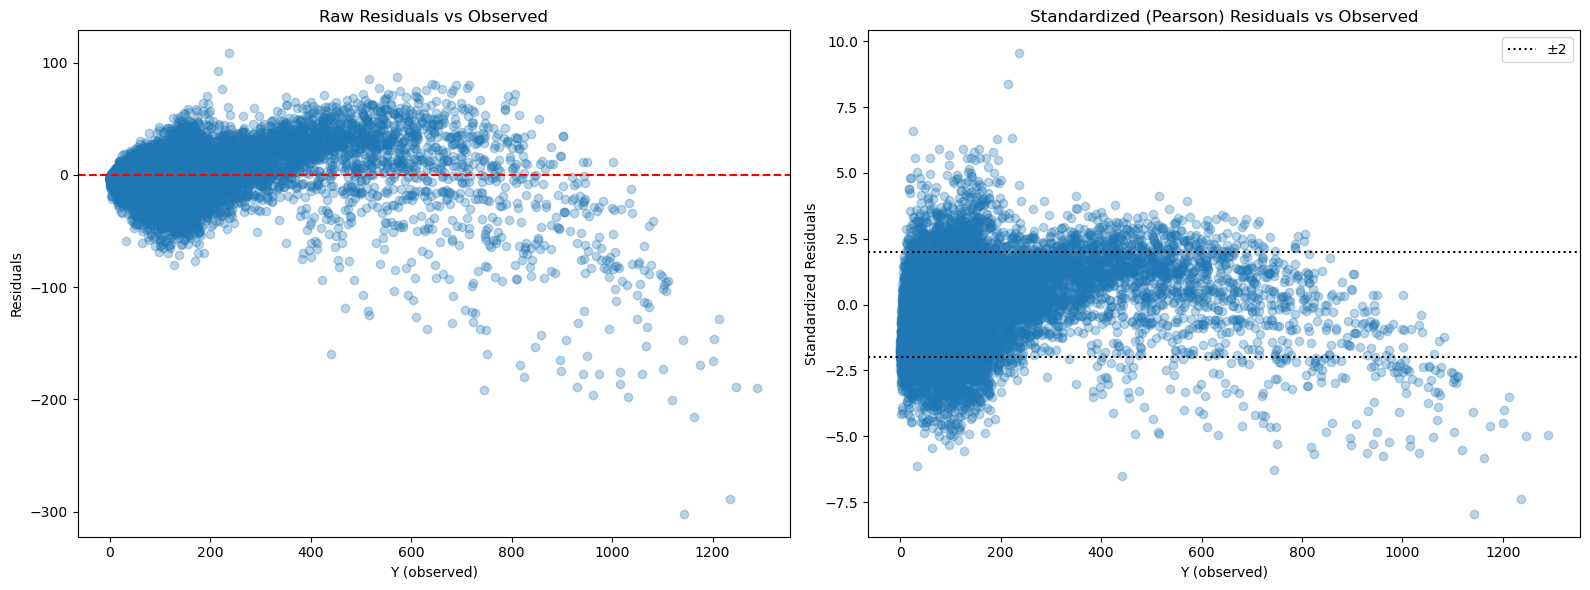

In [13]:
resid_pearson = poisson_model.resid_pearson

within_2sd = ((resid_pearson > -2) & (resid_pearson < 2)).sum()
total = len(resid_pearson)
pct = within_2sd / total * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(Y, poisson_model.resid_response, alpha=0.3)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_ylabel("Residuals")
axes[0].set_xlabel("Y (observed)")
axes[0].set_title("Raw Residuals vs Observed")

axes[1].scatter(Y, resid_pearson, alpha=0.3)
axes[1].axhline(y=-2, linestyle=':', color='black', label='±2')
axes[1].axhline(y=+2, linestyle=':', color='black')
axes[1].set_ylabel("Standardized Residuals")
axes[1].set_xlabel("Y (observed)")
axes[1].set_title("Standardized (Pearson) Residuals vs Observed")
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
R = poisson_model.pearson_chi2 / poisson_model.df_resid
print(f"Overdispersion parameter (Pearson chi² / df_resid): {R:.3f}")
print(f"Expected for Poisson: ≈ 1.0")
print()

df_resid = poisson_model.df_resid
p_value = 1 - chi2.cdf(poisson_model.pearson_chi2, df_resid)

print(f"Pearson Chi-Square statistic: {poisson_model.pearson_chi2:.3f}")
print(f"Degrees of freedom: {df_resid}")
print(f"Chi-Square Test p-value: {p_value:.3f}")
print()


Overdispersion parameter (Pearson chi² / df_resid): 2.853
Expected for Poisson: ≈ 1.0

Pearson Chi-Square statistic: 28505.154
Degrees of freedom: 9992
Chi-Square Test p-value: 0.000



<div style="direction: rtl; text-align: right; font-family: Arial, sans-serif; line-height: 1.8; max-width: 800px; margin: 0 auto; color: #333333;">

<h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 20px;">
    הערכת טיב ההתאמה של מודל פואסון
</h3>

<div style="margin-bottom: 20px;">
    <span style="display: block; font-weight: bold; color: #2c3e50; font-size: 1.1em; margin-bottom: 6px;">
        הנחת היסוד התיאורטית:
    </span>
    <p style="margin: 0; text-align: justify;">
        רגרסיה פואסונית מניחה שוויון בין התוחלת לשונות ($E[Y] = Var(Y)$), כלומר שהפיזור בנתוני הספירה תואם את הממוצע שלהם. הנחה זו מהווה את הבסיס למודל פואסון ככלי מתאים לנתוני ספירה של מקרים בלתי תלויים. ניתן לראות שאין שווין ביניהם ולכן הנחת הבסיס לרגרסיה פואסונית לא מתאימה לפי בדיקה זו.
    </p>
</div>

<div style="margin-bottom: 20px;">
    <span style="display: block; font-weight: bold; color: #2c3e50; font-size: 1.1em; margin-bottom: 6px;">
        ניתוח שאריות:
    </span>
    <p style="margin: 0; text-align: justify;">
        גרף השאריות (Residuals vs Fitted) מציג תבנית קשתית מובהקת במקום ענן נקודות אקראי, לצד חריגה נרחבת מגבולות אזור הערך 2 בשאריות הסטנדרטיות, מה שמוכיח כי המודל אינו מצליח לתפוס נכונה את הקשר הלא-ליניארי בנתונים ואת השונות הגבוהה שאינה עומדת בהנחת היסוד הפואסונית.
    </p>
</div>
    
<div style="margin-bottom: 20px;">
    <span style="display: block; font-weight: bold; color: #2c3e50; font-size: 1.1em; margin-bottom: 6px;">
        ממצאי בדיקות ההתאמה:
    </span>
    <p style="margin: 0; text-align: justify;">
        בבדיקת המודל בפועל, התקבלו הערכים הבאים: <strong>Pearson Chi-Square: 28,505.154</strong> (עבור 9,992 דרגות חופש, $p\text{-value} = 0.000$), ו-<strong>Dispersion Ratio: 2.853</strong>. ערכים אלו מצביעים על חריגה מהותית מהנחת היסוד התיאורטית לעיל, שכן ה-Dispersion Ratio הגבוה מ-1 (מצופה $\approx 1.0$) מעיד על פיזור יתר (Overdispersion) בנתונים.
    </p>
</div>


<div>
    <span style="display: block; font-weight: bold; color: #2c3e50; font-size: 1.1em; margin-bottom: 6px;">
        מסקנה:
    </span>
    <p style="margin: 0; text-align: justify;">
        על אף שמודל פואסון מהווה נקודת מוצא תיאורטית מתאימה לנתוני ספירה, תוצאות הבדיקות הנוכחיות מלמדות כי המודל הפואסוני הפשוט אינו מסביר בצורה מספקת את השונות בנתונים שלנו, ונדרשת בחינה של מודלים מורכבים יותר המסוגלים להתמודד עם פיזור יתר.
    </p>
</div>

</div>

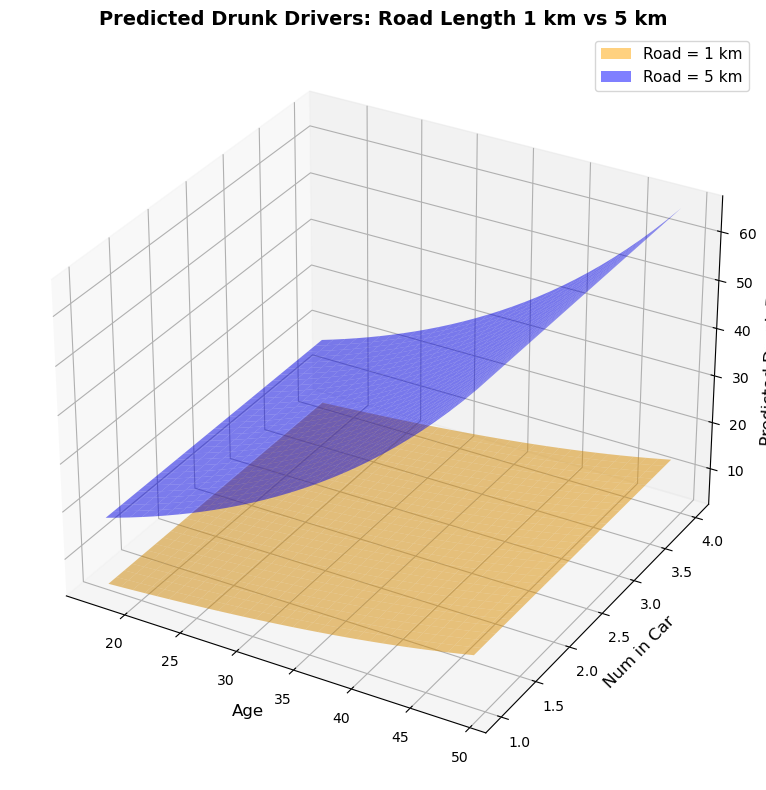

In [15]:
age_vals = np.linspace(df_1['age'].min(), df_1['age'].max(), 30)
num_vals = np.linspace(df_1['num_in_car'].min(), df_1['num_in_car'].max(), 30)
AGE, NUM = np.meshgrid(age_vals, num_vals)

model_columns = poisson_model.model.exog_names  

def build_pred_df(age_arr, num_arr):
    n = age_arr.size
    pred_df = pd.DataFrame(0.0, index=range(n), columns=model_columns)
    pred_df['const'] = 1.0
    pred_df['age'] = age_arr.ravel()
    pred_df['num_in_car'] = num_arr.ravel()
    if 'liscene_year' in model_columns:
        pred_df['liscene_year'] = df_1['liscene_year'].mean()
    return pred_df

pred_df = build_pred_df(AGE, NUM)


linear_pred = poisson_model.predict(pred_df, which="linear")

Z1 = (np.exp(linear_pred + np.log(1))).values.reshape(AGE.shape)  
Z5 = (np.exp(linear_pred + np.log(5))).values.reshape(AGE.shape)  

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(AGE, NUM, Z1, alpha=0.5, color='orange')
ax.plot_surface(AGE, NUM, Z5, alpha=0.5, color='blue')

ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Num in Car', fontsize=12)
ax.set_zlabel('Predicted Drunk Drivers', fontsize=12)
ax.set_title('Predicted Drunk Drivers: Road Length 1 km vs 5 km', fontsize=14, fontweight='bold')

legend_elements = [Patch(facecolor='orange', alpha=0.5, label='Road = 1 km'),
                   Patch(facecolor='blue', alpha=0.5, label='Road = 5 km')]
ax.legend(handles=legend_elements, fontsize=11)

plt.tight_layout()
plt.show()


<div style="direction: rtl; text-align: right; font-family: Arial, sans-serif; line-height: 1.8; max-width: 800px; margin: 0 auto; color: #333333;">

<h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 20px;">
    ניתוח גרפי: חיזוי מספר נהגים שיכורים
</h3>

<div style="margin-bottom: 20px;">
    <span style="display: block; font-weight: bold; color: #2c3e50; font-size: 1.1em; margin-bottom: 6px;">
        מה אנחנו רואים בגרף?
    </span>
    <p style="margin: 0; text-align: justify;">
        הגרף מציג את מספר הנהגים השיכורים החזוי (ציר ה-Z) כפונקציה של גיל הנהג (Age) ומספר הנוסעים ברכב (Num in Car). 
        המישור הכחול העליון מייצג חיזוי עבור כביש באורך 5 ק"מ, בעוד המישור הכתום/צהוב התחתון מייצג חיזוי עבור כביש באורך 1 ק"מ.
    </p>
</div>

<div style="margin-bottom: 20px;">
    <span style="display: block; font-weight: bold; color: #2c3e50; font-size: 1.1em; margin-bottom: 6px;">
        הסבר לתוצאות
    </span>
    <p style="margin: 0; text-align: justify;">
        ניתן להבחין בהבדל מובהק בגובה המישורים: ככל שאורך הכביש (משתנה החשיפה) עולה, התוחלת של מספר האירועים החזויים עולה באופן פרופורציונלי. 
        זהו ביטוי גרפי להנחת המודל הפואסוני, לפיה ה"חשיפה" משפיעה ליניארית על קצב האירועים. ככל שיש יותר מרחק לנסיעה, כך סביר יותר שיתרחשו יותר אירועים של נהיגה בשכרות.
    </p>
</div>

<div>
    <span style="display: block; font-weight: bold; color: #2c3e50; font-size: 1.1em; margin-bottom: 6px;">
        מסקנה
    </span>
    <p style="margin: 0; text-align: justify;">
        התוצאה הגיונית מבחינה סטטיסטית ומעשית. המודל תופס את העובדה שכביש ארוך יותר מאפשר יותר מפגשים עם נהגים שיכורים, ולכן המישור של 5 ק"מ נמצא בערכי Z גבוהים יותר באופן עקבי לאורך כל טווח הגילאים ומספר הנוסעים.
    </p>
</div>

</div>